<a href="https://colab.research.google.com/github/Meghali54/AI_Browser_Automation/blob/main/SQL_Movie_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SQL Movie Rental Analysis

This notebook analyzes the given SQL data using SQLite and Python (pandas).

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

In [3]:
cursor.executescript("""
DROP TABLE IF EXISTS invoice;
DROP TABLE IF EXISTS movie;
DROP TABLE IF EXISTS customer;

CREATE TABLE customer(
    cust_id TEXT PRIMARY KEY,
    f_name TEXT,
    l_name TEXT,
    area TEXT,
    ph_no INTEGER
);

CREATE TABLE movie(
    mv_no INTEGER PRIMARY KEY,
    title TEXT,
    type TEXT,
    star TEXT,
    price INTEGER
);

CREATE TABLE invoice(
    inv_no TEXT PRIMARY KEY,
    mv_no INTEGER,
    cust_id TEXT,
    issue_date TEXT,
    return_date TEXT,
    FOREIGN KEY(mv_no) REFERENCES movie(mv_no),
    FOREIGN KEY(cust_id) REFERENCES customer(cust_id)
);
""")
conn.commit()

In [4]:
cursor.executescript("""
INSERT INTO customer VALUES('a01','Ivan','Bayross','sa',6125467);
INSERT INTO customer VALUES('a02','Vandana','Saiteal','mu',5560379);
INSERT INTO customer VALUES('a03','Pramedo','Jauguste','da',4560389);
INSERT INTO customer VALUES('a04','Basu','Navindgi','ba',6125401);
INSERT INTO customer VALUES('a05','Ravi','Sreedharm','na',NULL);
INSERT INTO customer VALUES('a06','Rukmini',NULL,'gh',512574);

INSERT INTO movie VALUES(1,'Bloody','Action','Jacki Chang',181);
INSERT INTO movie VALUES(2,'The Firm','Thriller','Tom Cruise',200);
INSERT INTO movie VALUES(3,'Pretty Woman','Romance','Richard Gere',151);
INSERT INTO movie VALUES(4,'Home Alone','Comedy','Macaulay Culkin',150);
INSERT INTO movie VALUES(5,'The Fugitive','Thriller','Marison Ford',200);
INSERT INTO movie VALUES(6,'Coma','Suspense','Michael Douglas',100);
INSERT INTO movie VALUES(7,'Dracula','Horror','Grey Oldman',100);
INSERT INTO movie VALUES(8,'Quick Change','Comedy','Bill Mauray',100);
INSERT INTO movie VALUES(9,'Gone with the wind','Action','Clark Gable',200);
INSERT INTO movie VALUES(10,'Carry on Doctor','Comedy','Leslie Philips',100);

INSERT INTO invoice VALUES('i01',4,'a01','1993-07-23','1993-07-25');
INSERT INTO invoice VALUES('i02',3,'a02','1993-08-12','1993-08-15');
INSERT INTO invoice VALUES('i03',1,'a02','1993-08-15','1993-08-18');
INSERT INTO invoice VALUES('i04',6,'a03','1993-09-10','1993-09-13');
INSERT INTO invoice VALUES('i05',7,'a04','1993-08-05','1993-08-08');
INSERT INTO invoice VALUES('i06',2,'a06','1993-09-18','1993-09-21');
INSERT INTO invoice VALUES('i07',9,'a05','1993-07-07','1993-07-10');
INSERT INTO invoice VALUES('i08',9,'a01','1993-08-11','1993-08-14');
INSERT INTO invoice VALUES('i09',5,'a03','1993-07-06','1993-07-09');
INSERT INTO invoice VALUES('i10',8,'a06','1993-09-03','1993-09-06');
""")
conn.commit()

In [5]:
customer_df = pd.read_sql('SELECT * FROM customer', conn)
movie_df = pd.read_sql('SELECT * FROM movie', conn)
invoice_df = pd.read_sql('SELECT * FROM invoice', conn)

display(customer_df.head())
display(movie_df.head())
display(invoice_df.head())

,cust_id,f_name,l_name,area,ph_no
0,a01,Ivan,Bayross,sa,6125467.0
1,a02,Vandana,Saiteal,mu,5560379.0
2,a03,Pramedo,Jauguste,da,4560389.0
3,a04,Basu,Navindgi,ba,6125401.0
4,a05,Ravi,Sreedharm,na,NaN


,mv_no,title,type,star,price
0,1,Bloody,Action,Jacki Chang,181
1,2,The Firm,Thriller,Tom Cruise,200
2,3,Pretty Woman,Romance,Richard Gere,151
3,4,Home Alone,Comedy,Macaulay Culkin,150
4,5,The Fugitive,Thriller,Marison Ford,200


,inv_no,mv_no,cust_id,issue_date,return_date
0,i01,4,a01,1993-07-23,1993-07-25
1,i02,3,a02,1993-08-12,1993-08-15
2,i03,1,a02,1993-08-15,1993-08-18
3,i04,6,a03,1993-09-10,1993-09-13
4,i05,7,a04,1993-08-05,1993-08-08


In [6]:
query = '''
SELECT m.type, COUNT(*) AS total_rentals
FROM movie m
JOIN invoice i ON m.mv_no = i.mv_no
GROUP BY m.type
'''
rentals_by_type = pd.read_sql(query, conn)
rentals_by_type

,type,total_rentals
0,Action,3
1,Comedy,2
2,Horror,1
3,Romance,1
4,Suspense,1
5,Thriller,2


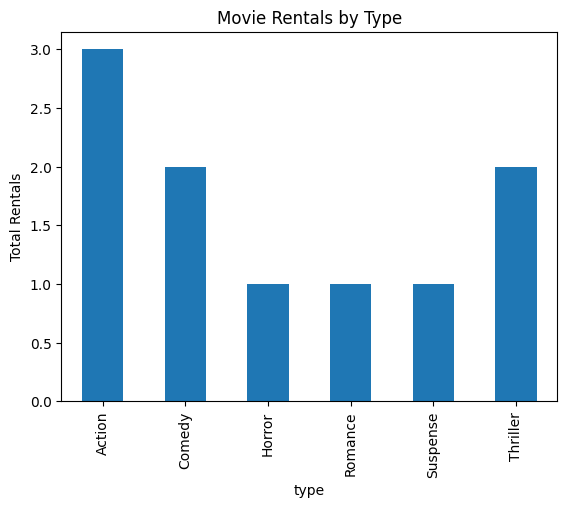

In [7]:
rentals_by_type.plot(kind='bar', x='type', y='total_rentals', legend=False)
plt.title('Movie Rentals by Type')
plt.ylabel('Total Rentals')
plt.show()

Select all rows of Customer Table

In [8]:
customer_all_rows_df = pd.read_sql('SELECT * FROM customer', conn)
display(customer_all_rows_df)

,cust_id,f_name,l_name,area,ph_no
0,a01,Ivan,Bayross,sa,6125467.0
1,a02,Vandana,Saiteal,mu,5560379.0
2,a03,Pramedo,Jauguste,da,4560389.0
3,a04,Basu,Navindgi,ba,6125401.0
4,a05,Ravi,Sreedharm,na,NaN
5,a06,Rukmini,None,gh,512574.0


# Task
Perform a comprehensive analysis of the movie rental database. This includes: selecting customer IDs and full names, filtering customers by first name initial 'R', selecting movies by title containing 't' or 'T', selecting customer IDs for invoices before '1993-08-31', updating a customer's phone number, adding and then deleting a 'mail_id' column in the customer table, analyzing and visualizing the top customers by rental count using an interactive bar chart, and analyzing and visualizing movie prices by type using an interactive box plot. Finally, provide a comprehensive summary of all SQL queries, data manipulations, and insights gained from the generated interactive charts.

## Select Customer ID and Full Name

### Subtask:
Select the customer ID as 'Customer_ID_Number' and concatenate first name and last name as 'Full Name' from the customer table.


**Reasoning**:
To select the customer ID and concatenate the first and last names as 'Full Name', I will construct a SQL query using SQLite's concatenation operator (||) and column aliasing, then execute it with `pd.read_sql` and display the head of the resulting DataFrame.



In [9]:
query = """SELECT cust_id AS 'Customer_ID_Number', f_name || ' ' || l_name AS 'Full Name' FROM customer"""
customer_full_names_df = pd.read_sql(query, conn)
display(customer_full_names_df.head())

,Customer_ID_Number,Full Name
0,a01,Ivan Bayross
1,a02,Vandana Saiteal
2,a03,Pramedo Jauguste
3,a04,Basu Navindgi
4,a05,Ravi Sreedharm


## Select Customers by First Name Initial 'R'

### Subtask:
Select customer details for all customers whose first name starts with the letter 'R' from the customer table.


**Reasoning**:
To select customer details where the first name starts with 'R', I will construct a SQL query using the LIKE operator with a wildcard, execute it using `pd.read_sql`, and display the head of the resulting DataFrame.



In [10]:
query = """SELECT * FROM customer WHERE f_name LIKE 'R%'"""
customers_with_r_initial_df = pd.read_sql(query, conn)
display(customers_with_r_initial_df.head())

,cust_id,f_name,l_name,area,ph_no
0,a05,Ravi,Sreedharm,na,NaN
1,a06,Rukmini,None,gh,512574.0


## Select Movies by Title Containing 't' or 'T'

### Subtask:
Select movie number and movie title from the movie table for titles that contain 't' or 'T'.


**Reasoning**:
To select movies with titles containing 't' or 'T' in a case-insensitive manner, I will construct a SQL query using the LIKE operator with wildcards and the GLOB keyword for case-insensitivity in SQLite, then execute it with `pd.read_sql` and display the head of the resulting DataFrame.



In [11]:
query = """SELECT mv_no, title FROM movie WHERE title LIKE '%t%' OR title LIKE '%T%'"""
movies_with_t_df = pd.read_sql(query, conn)
display(movies_with_t_df.head())

,mv_no,title
0,2,The Firm
1,3,Pretty Woman
2,5,The Fugitive
3,9,Gone with the wind
4,10,Carry on Doctor


## Select Customer IDs for Invoices Before Aug 31, 1993

### Subtask:
Select customer IDs from the invoice table where the 'issue_date' is before '1993-08-31'.


**Reasoning**:
To select unique customer IDs from the invoice table for invoices issued before '1993-08-31', I will construct a SQL query using the WHERE clause with a date comparison and the DISTINCT keyword, execute it with `pd.read_sql`, and display the head of the resulting DataFrame.



In [12]:
query = """SELECT DISTINCT cust_id FROM invoice WHERE issue_date < '1993-08-31'"""
customer_ids_pre_aug_31_df = pd.read_sql(query, conn)
display(customer_ids_pre_aug_31_df.head())

,cust_id
0,a01
1,a02
2,a04
3,a05
4,a03


## Update Customer Phone Number

### Subtask:
Update the phone number for the customer with 'cust_id' 'a06' in the customer table. I will use a placeholder number for this update.


**Reasoning**:
To update the phone number for the customer with `cust_id` 'a06', I will construct an SQL `UPDATE` statement. This statement will set the `ph_no` column to a new value for the specified `cust_id`. I will then execute this statement using `cursor.execute()` and commit the transaction using `conn.commit()` to persist the changes in the database. Finally, to confirm the update, I will re-query the entire `customer` table into a Pandas DataFrame and display its contents.

**Reasoning**:
To implement the update of the phone number for customer 'a06', I will use a SQL UPDATE statement, execute it via the cursor, commit the changes, and then reload and display the customer table to confirm the update.



In [13]:
cursor.execute("UPDATE customer SET ph_no = 9999999999 WHERE cust_id = 'a06'")
conn.commit()

customer_df_updated = pd.read_sql('SELECT * FROM customer', conn)
display(customer_df_updated)

,cust_id,f_name,l_name,area,ph_no
0,a01,Ivan,Bayross,sa,6.125467e+06
1,a02,Vandana,Saiteal,mu,5.560379e+06
2,a03,Pramedo,Jauguste,da,4.560389e+06
3,a04,Basu,Navindgi,ba,6.125401e+06
4,a05,Ravi,Sreedharm,na,NaN
5,a06,Rukmini,None,gh,1.000000e+10


## Add and Update Mail ID Column

### Subtask:
Add a new column named 'mail_id' to the customer table and then update all entries in this column with the value 'abc@gmail.com'.


**Reasoning**:
To add a new column 'mail_id' to the customer table, I will use an `ALTER TABLE ADD COLUMN` SQL statement. This will modify the schema of the customer table to include the new column.



In [14]:
cursor.execute("ALTER TABLE customer ADD COLUMN mail_id TEXT")
conn.commit()

**Reasoning**:
To update all entries in the newly added 'mail_id' column to 'abc@gmail.com' for all customers, I will use an SQL `UPDATE` statement. This statement will set the `mail_id` column to the specified value for all rows in the `customer` table. After the update, I will commit the changes to the database and then re-query the `customer` table to display the updated DataFrame, confirming that the new column has been populated correctly.



In [15]:
cursor.execute("UPDATE customer SET mail_id = 'abc@gmail.com'")
conn.commit()

customer_df_with_mailid = pd.read_sql('SELECT * FROM customer', conn)
display(customer_df_with_mailid)

,cust_id,f_name,l_name,area,ph_no,mail_id
0,a01,Ivan,Bayross,sa,6.125467e+06,abc@gmail.com
1,a02,Vandana,Saiteal,mu,5.560379e+06,abc@gmail.com
2,a03,Pramedo,Jauguste,da,4.560389e+06,abc@gmail.com
3,a04,Basu,Navindgi,ba,6.125401e+06,abc@gmail.com
4,a05,Ravi,Sreedharm,na,NaN,abc@gmail.com
5,a06,Rukmini,None,gh,1.000000e+10,abc@gmail.com


**Reasoning**:
To delete the 'mail_id' column from the customer table, I will use an `ALTER TABLE DROP COLUMN` SQL statement. This will modify the schema of the customer table by removing the specified column. After removing the column, I will commit the changes to the database and then re-query the `customer` table to display the updated DataFrame, confirming that the 'mail_id' column has been successfully removed.



In [16]:
cursor.execute("ALTER TABLE customer DROP COLUMN mail_id")
conn.commit()

customer_df_without_mailid = pd.read_sql('SELECT * FROM customer', conn)
display(customer_df_without_mailid)

,cust_id,f_name,l_name,area,ph_no
0,a01,Ivan,Bayross,sa,6.125467e+06
1,a02,Vandana,Saiteal,mu,5.560379e+06
2,a03,Pramedo,Jauguste,da,4.560389e+06
3,a04,Basu,Navindgi,ba,6.125401e+06
4,a05,Ravi,Sreedharm,na,NaN
5,a06,Rukmini,None,gh,1.000000e+10


## Analyze Top Customers by Rental Count

### Subtask:
Identify the top customers based on the number of movies they have rented. This will involve joining the customer and invoice tables.


**Reasoning**:
To identify the top customers by rental count, I will construct a SQL query that joins the `customer` and `invoice` tables, groups by customer details, counts the invoices, and orders the results by rental count.



In [17]:
query = '''
SELECT
    c.cust_id,
    c.f_name || ' ' || c.l_name AS full_name,
    COUNT(i.inv_no) AS rental_count
FROM
    customer c
JOIN
    invoice i ON c.cust_id = i.cust_id
GROUP BY
    c.cust_id, full_name
ORDER BY
    rental_count DESC
'''
top_customers_df = pd.read_sql(query, conn)
display(top_customers_df.head())

,cust_id,full_name,rental_count
0,a01,Ivan Bayross,2
1,a02,Vandana Saiteal,2
2,a03,Pramedo Jauguste,2
3,a06,None,2
4,a04,Basu Navindgi,1


## Visualize Top Customers by Rental Count

### Subtask:
Create an interactive bar chart to visualize the top customers and their respective rental counts, providing clear labels and a title.


**Reasoning**:
To create an interactive bar chart for visualizing the top customers by rental count, I will use `matplotlib.pyplot` to generate a bar chart from the `top_customers_df` DataFrame, setting `full_name` for the x-axis, `rental_count` for the y-axis, and then apply appropriate labels and a title before displaying the plot.



**Reasoning**:
The previous code failed because the 'full_name' column in 'top_customers_df' contained a 'None' value, which Matplotlib cannot handle directly for categorical labels. To resolve this, I will fill any 'None' values in the 'full_name' column with an empty string before plotting, ensuring all labels are valid strings.



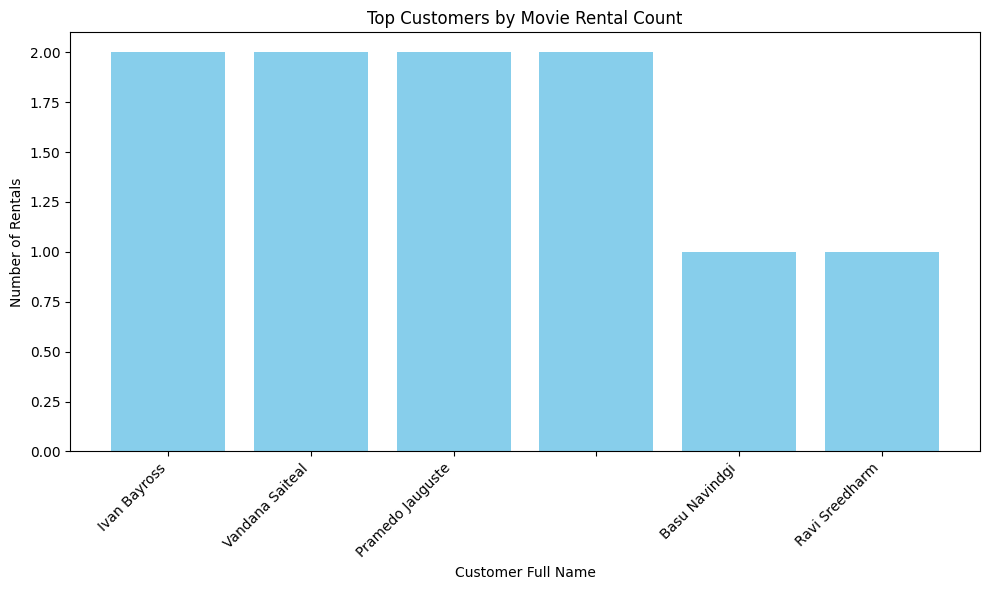

In [19]:
top_customers_df['full_name'] = top_customers_df['full_name'].fillna('')
plt.figure(figsize=(10, 6))
plt.bar(top_customers_df['full_name'], top_customers_df['rental_count'], color='skyblue')
plt.xlabel('Customer Full Name')
plt.ylabel('Number of Rentals')
plt.title('Top Customers by Movie Rental Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()